# Exercise 1
### meiermis

## 1. Use cases

#### 1.1 Selected use cases
1. Keeping and enhancing Shorthaul PAX, regional Cargo and GA
Keeping what we already have as core revenue and value creation driver shall stay primary focus and priority

2. UAM PAX Transport:
eVTOL Aircraft for short range PAX transport (mostly airport shuttle and back) to the city center 70km away seems feasable

3. UAV Logistics:
Could be applicable to our airport, mostly for incoming regional Cargo via Airplane that can then be switched to UAV for further delivery to a main cargo hub closer to the city center for delivery.



#### 1.2 Required Infrastructure and users

- Vertiports for UAV/UAM
- Dedicated Drone Approach/Departure segments that do not interfere traditional OPS
- Electric Charging and Storage infrastructure
- Cargo transfer site from inbound aircraft to drones.

- eVTOL sharing companies could become new users
- Growth of conventional traffic.

Points 2 and 3 regarding UAM/UAV are more in a 20-50 years horizon and therefore should be kept as options in a dynamic forecast. A high uncertainty regarding regulations and technology development is still present.

## 2. GBM Demand Scenarios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
aerovale_demand = pd.read_csv("aerovale_demand.csv", sep=";")
aerovale_demand.head()

,Year,Flight_Movements,Passengers
0,1982,18500,210000
1,1983,18800,218000
2,1984,19100,225000
3,1985,19500,235000
4,1986,19800,245000


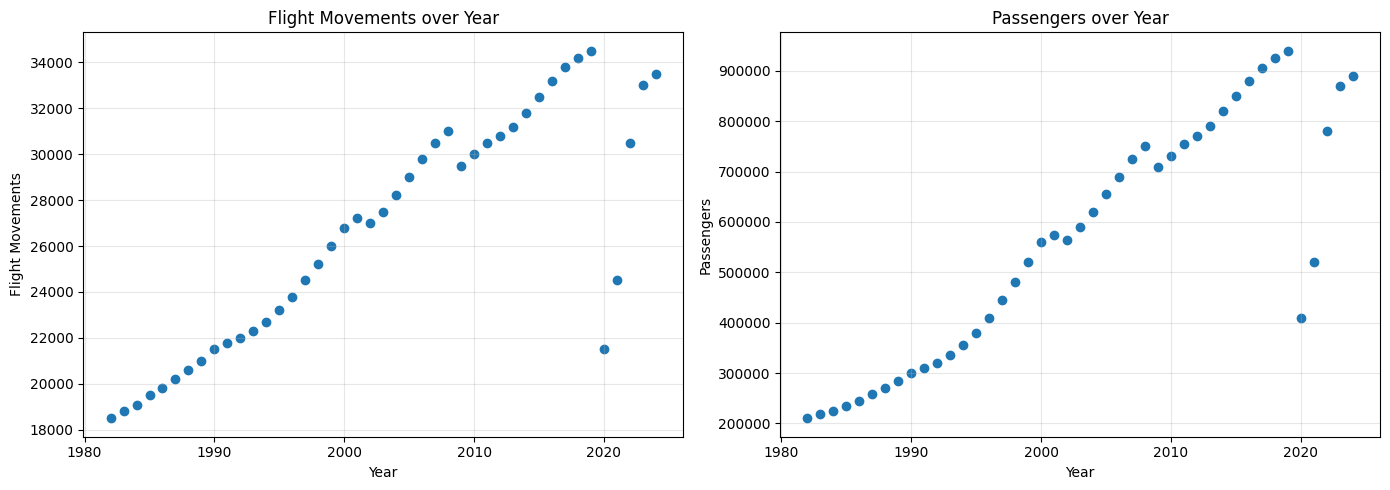

In [3]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(aerovale_demand['Year'], aerovale_demand['Flight_Movements'])
ax1.set_xlabel('Year')
ax1.set_ylabel('Flight Movements')
ax1.set_title('Flight Movements over Year')
ax1.grid(True, alpha=0.3)

ax2.scatter(aerovale_demand['Year'], aerovale_demand['Passengers'])
ax2.set_xlabel('Year')
ax2.set_ylabel('Passengers')
ax2.set_title('Passengers over Year')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Demand Cleaned is removing the years 2020, 2021 and 2022 as second demand option

In [4]:
#remove the year 2020, 2021 and 2022, because of the covid-19 pandemic
aerovale_demand_cleaned = aerovale_demand[(aerovale_demand['Year'] != 2020) & (aerovale_demand['Year'] != 2021) & (aerovale_demand['Year'] != 2022)]


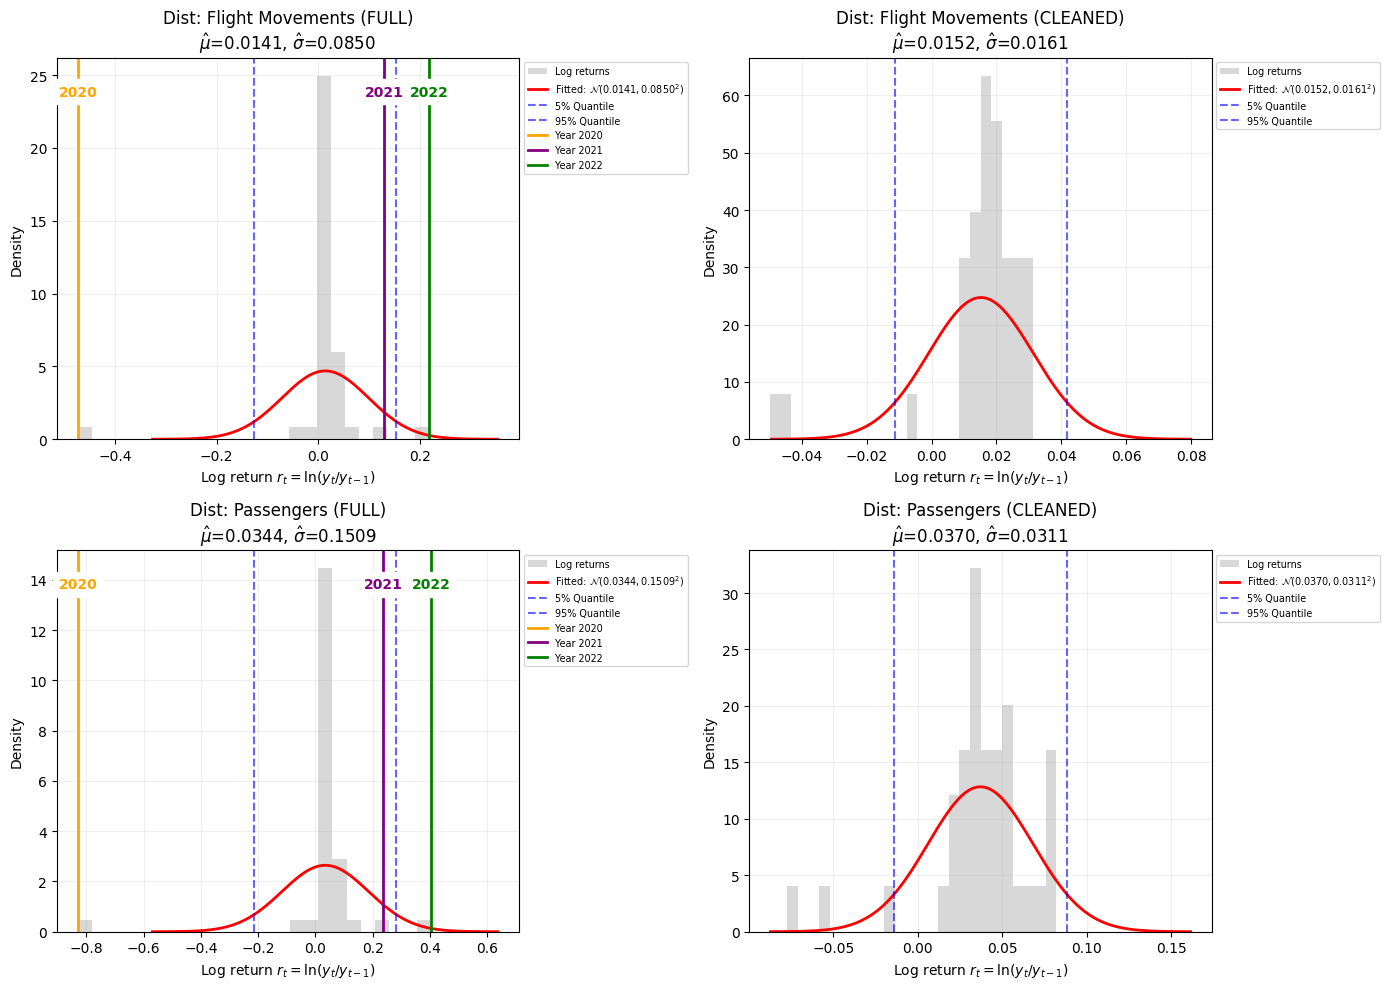

In [9]:
import scipy.stats as stats

def plot_log_return_distribution(ax, df, col, title):
    # 1. Calculate historical log-returns with index preserved
    lr_series = np.log(df[col] / df[col].shift(1)).dropna()
    
    # 2. Get parameters
    mu_hat, sigma_hat = fit_mu_sigma(df, col)
    
    # 3. Plot Histogram
    ax.hist(lr_series, bins=25, density=True, alpha=0.3, color='gray', label='Log returns')
    
    # 4. Generate the Normal PDF curve
    x = np.linspace(mu_hat - 4*sigma_hat, mu_hat + 4*sigma_hat, 200)
    pdf = stats.norm.pdf(x, mu_hat, sigma_hat)
    ax.plot(x, pdf, 'r-', lw=2, label=f'Fitted: $\mathcal{{N}}({mu_hat:.4f}, {sigma_hat:.4f}^2)$')
    
    # 5. Add Vlines for 5% and 95% theoretical quantiles
    p05 = stats.norm.ppf(0.05, mu_hat, sigma_hat)
    p95 = stats.norm.ppf(0.95, mu_hat, sigma_hat)
    ax.axvline(p05, color='blue', linestyle='--', alpha=0.6, label='5% Quantile')
    ax.axvline(p95, color='blue', linestyle='--', alpha=0.6, label='95% Quantile')
    
    # 6. Highlight specific years (2020, 2021, 2022)
    # We map back to the 'Year' column in the original dataframe
    special_years = [2020, 2021, 2022]
    colors = ['orange', 'purple', 'green']
    
    for year, color in zip(special_years, colors):
        if year in df['Year'].values:
            # The log return for 2020 is ln(Y_2020 / Y_2019)
            # We locate the index where Year == year
            val = lr_series.get(df[df['Year'] == year].index[0], None)
            if val is not None:
                ax.axvline(val, color=color, lw=2, label=f'Year {year}')
                # Add text label at the top
                ax.text(val, ax.get_ylim()[1]*0.9, f'{year}', color=color, 
                        fontweight='bold', ha='center', backgroundcolor='white')

    # Formatting
    ax.set_title(title)
    ax.set_xlabel(r"Log return $r_t = \ln(y_t/y_{t-1})$")
    ax.set_ylabel("Density")
    ax.legend(fontsize='x-small', loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True, alpha=0.2)

# --- The rest of your plotting calls (fig_dist, axes_dist...) remain the same ---

# ---------------------------------------------------------
# Create the Diagnostic Plot (2x2 Distribution view)
# ---------------------------------------------------------
fig_dist, axes_dist = plt.subplots(2, 2, figsize=(14, 10))

plot_log_return_distribution(
    axes_dist[0, 0], full, "Flight_Movements", 
    f"Dist: Flight Movements (FULL)\n$\hat{{\mu}}$={mu_f_full:.4f}, $\hat{{\sigma}}$={sig_f_full:.4f}"
)

plot_log_return_distribution(
    axes_dist[0, 1], clean, "Flight_Movements", 
    f"Dist: Flight Movements (CLEANED)\n$\hat{{\mu}}$={mu_f_clean:.4f}, $\hat{{\sigma}}$={sig_f_clean:.4f}"
)

plot_log_return_distribution(
    axes_dist[1, 0], full, "Passengers", 
    f"Dist: Passengers (FULL)\n$\hat{{\mu}}$={mu_p_full:.4f}, $\hat{{\sigma}}$={sig_p_full:.4f}"
)

plot_log_return_distribution(
    axes_dist[1, 1], clean, "Passengers", 
    f"Dist: Passengers (CLEANED)\n$\hat{{\mu}}$={mu_p_clean:.4f}, $\hat{{\sigma}}$={sig_p_clean:.4f}"
)

plt.tight_layout()
plt.show()

Estimated parameters for Flight Movements (Filtered): mu=0.0184, sigma=0.0162
Estimated parameters for Passengers (Filtered): mu=0.0418, sigma=0.0272


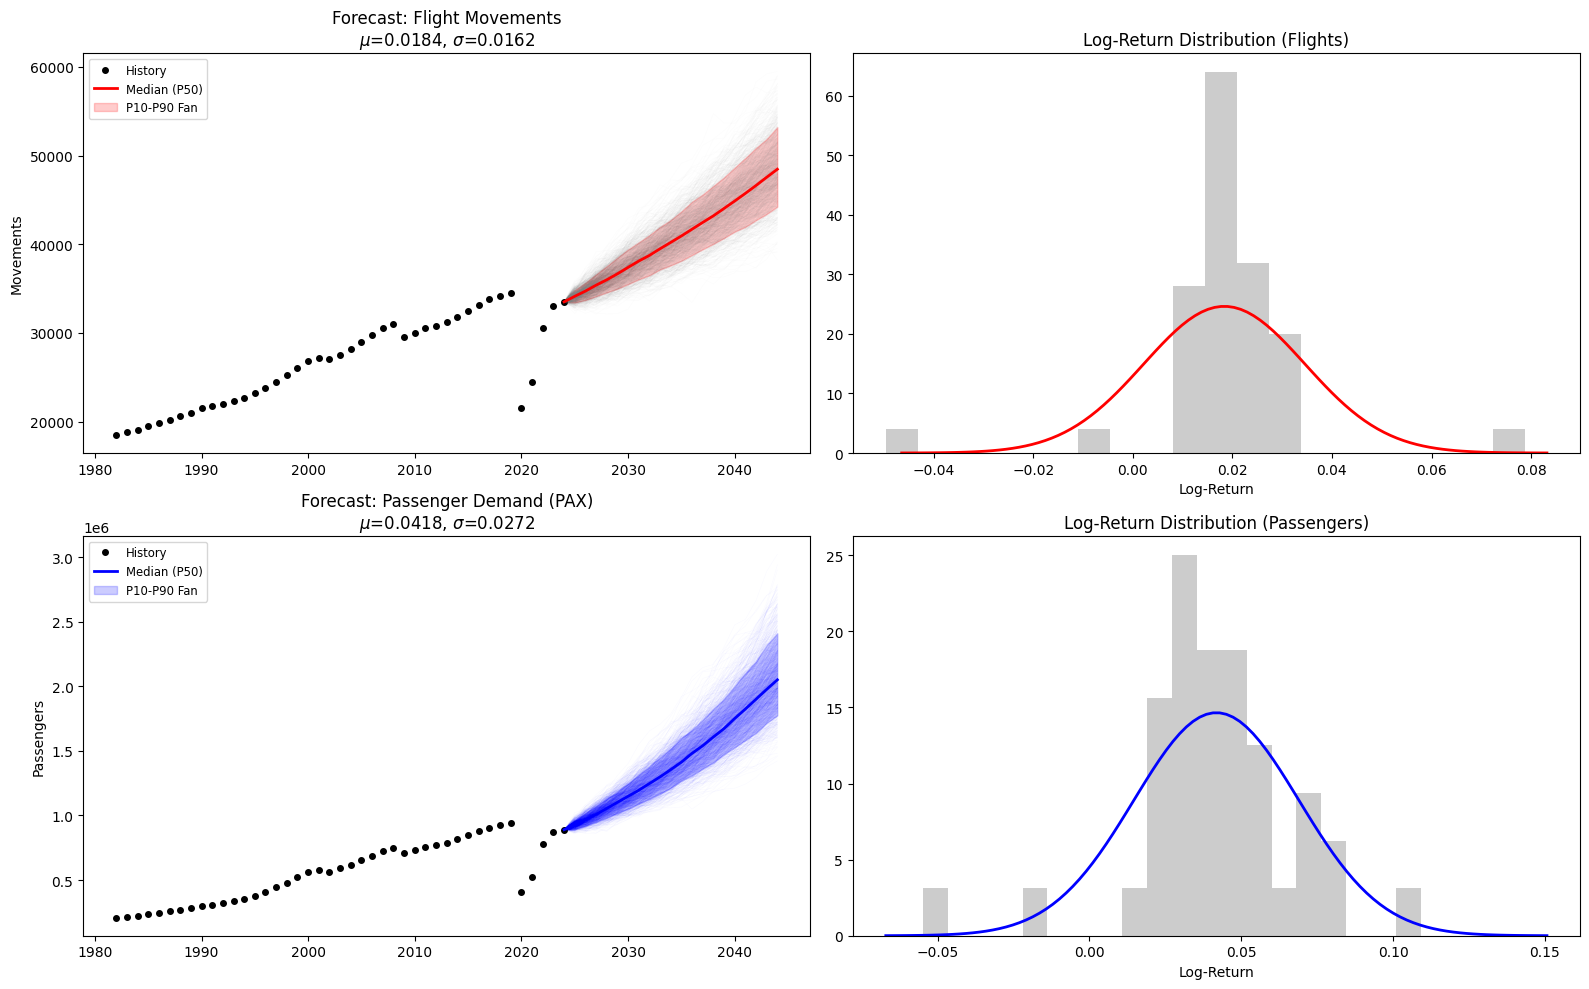

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# -----------------------
# Settings
# -----------------------
years_future = 20
dt = 1.0
n_paths = 1000
seed = 42
rng = np.random.default_rng(seed)

# -----------------------
# 1. Log-Return Fitting mit Ausreißer-Filter
# -----------------------
def fit_mu_sigma_filtered(df: pd.DataFrame, col: str, years_to_exclude=[2020, 2021, 2022]):
    df = df.sort_values("Year").copy()
    
    # Log-Returns berechnen: r_t = ln(Y_t / Y_{t-1})
    # Hinweis: Der Log-Return für Jahr X bezieht sich auf den Sprung von X-1 zu X
    df['log_return'] = np.log(df[col] / df[col].shift(1))
    
    # Die Log-Returns der extremen Jahre entfernen
    filtered_returns = df[~df['Year'].isin(years_to_exclude)]['log_return'].dropna()
    
    mu = float(filtered_returns.mean())
    sigma = float(filtered_returns.std(ddof=0))
    
    return mu, sigma, filtered_returns

# -----------------------
# 2. GBM Simulation (Logarithmisch)
# -----------------------
def simulate_gbm_logarithmic(D0: float, mu: float, sigma: float, years_future: int, n_paths: int, dt: float, rng):
    eps = rng.normal(0.0, 1.0, size=(years_future, n_paths))
    # Y_{t+dt} = Y_t * exp(mu*dt + sigma*eps*sqrt(dt))
    log_factors = np.exp(mu * dt + sigma * eps * np.sqrt(dt))
    
    paths = np.vstack([
        np.full((1, n_paths), D0), 
        D0 * np.cumprod(log_factors, axis=0)
    ])
    return paths

# -----------------------
# 3. Ausführung
# -----------------------

# Parameter fitten (auf Basis der gefilterten Full-Daten)
mu_f, sig_f, returns_f = fit_mu_sigma_filtered(aerovale_demand, "Flight_Movements")
mu_p, sig_p, returns_p = fit_mu_sigma_filtered(aerovale_demand, "Passengers")

# Startwerte (immer der aktuellste Wert aus dem Datensatz)
last_row = aerovale_demand.sort_values("Year").iloc[-1]
D0_f = float(last_row["Flight_Movements"])
D0_p = float(last_row["Passengers"])
last_year = int(last_row["Year"])

# Pfade simulieren
paths_f = simulate_gbm_logarithmic(D0_f, mu_f, sig_f, years_future, n_paths, dt, rng)
paths_p = simulate_gbm_logarithmic(D0_p, mu_p, sig_p, years_future, n_paths, dt, rng)

# Zeitachsen für Plots
years_all = np.arange(last_year, last_year + years_future + 1)

# -----------------------
# 4. Zusammenfassung in einem DataFrame
# -----------------------
q_levels = [0.10, 0.50, 0.90]
f_qs = np.quantile(paths_f, q_levels, axis=1)
p_qs = np.quantile(paths_p, q_levels, axis=1)

df_forecast = pd.DataFrame({
    'Year': years_all,
    'Flights_P10': f_qs[0], 'Flights_P50': f_qs[1], 'Flights_P90': f_qs[2],
    'Passengers_P10': p_qs[0], 'Passengers_P50': p_qs[1], 'Passengers_P90': p_qs[2]
})

# -----------------------
# 5. Output der mu und sigma Werte
# -----------------------
print(f"Estimated parameters for Flight Movements (Filtered): mu={mu_f:.4f}, sigma={sig_f:.4f}")
print(f"Estimated parameters for Passengers (Filtered): mu={mu_p:.4f}, sigma={sig_p:.4f}")

# -----------------------
# 6. Visualisierung (2 Panels: Forecast & Verteilung)
# -----------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- ROW 1: FLIGHT MOVEMENTS ---
# 1.1 Forecast
axes[0, 0].plot(aerovale_demand["Year"], aerovale_demand["Flight_Movements"], 'ko', label="History", markersize=4)
axes[0, 0].plot(years_all, paths_f, color='gray', alpha=0.02, lw=0.5)
axes[0, 0].plot(years_all, df_forecast['Flights_P50'], 'r-', lw=2, label="Median (P50)")
axes[0, 0].fill_between(years_all, df_forecast['Flights_P10'], df_forecast['Flights_P90'], color='red', alpha=0.2, label="P10-P90 Fan")
axes[0, 0].set_title(f"Forecast: Flight Movements\n$\mu$={mu_f:.4f}, $\sigma$={sig_f:.4f}")
axes[0, 0].set_ylabel("Movements")
axes[0, 0].legend(loc='upper left', fontsize='small')

# 1.2 Distribution
axes[0, 1].hist(returns_f, bins=20, density=True, alpha=0.4, color='gray')
x_f = np.linspace(mu_f - 4*sig_f, mu_f + 4*sig_f, 100)
axes[0, 1].plot(x_f, stats.norm.pdf(x_f, mu_f, sig_f), 'r-', lw=2, label="Normal Fit")
axes[0, 1].set_title("Log-Return Distribution (Flights)")
axes[0, 1].set_xlabel("Log-Return")

# --- ROW 2: PASSENGER (PAX) DEMAND ---
# 2.1 Forecast
axes[1, 0].plot(aerovale_demand["Year"], aerovale_demand["Passengers"], 'ko', label="History", markersize=4)
axes[1, 0].plot(years_all, paths_p, color='blue', alpha=0.02, lw=0.5) # Blue for PAX
axes[1, 0].plot(years_all, df_forecast['Passengers_P50'], 'b-', lw=2, label="Median (P50)")
axes[1, 0].fill_between(years_all, df_forecast['Passengers_P10'], df_forecast['Passengers_P90'], color='blue', alpha=0.2, label="P10-P90 Fan")
axes[1, 0].set_title(f"Forecast: Passenger Demand (PAX)\n$\mu$={mu_p:.4f}, $\sigma$={sig_p:.4f}")
axes[1, 0].set_ylabel("Passengers")
axes[1, 0].legend(loc='upper left', fontsize='small')

# 2.2 Distribution
axes[1, 1].hist(returns_p, bins=20, density=True, alpha=0.4, color='gray')
x_p = np.linspace(mu_p - 4*sig_p, mu_p + 4*sig_p, 100)
axes[1, 1].plot(x_p, stats.norm.pdf(x_p, mu_p, sig_p), 'b-', lw=2, label="Normal Fit")
axes[1, 1].set_title("Log-Return Distribution (Passengers)")
axes[1, 1].set_xlabel("Log-Return")

plt.tight_layout()
plt.savefig("exercise1_forecast_distribution.png", dpi=400)
plt.show()



In [14]:
# ---------------------------------------------------------
# Storage: 2D NumPy Arrays
# Vertical axis (Rows) = Time (T0, T1, ..., T20)
# Horizontal axis (Cols) = Scenarios (Path 1, Path 2, ..., Path 1000)
# ---------------------------------------------------------

# These arrays have the shape (21, 1000)
forecast_flights_array = paths_f
forecast_pax_array = paths_p

# Verify the shapes
print(f"Flights Array Shape (Time, Scenarios): {forecast_flights_array.shape}")
print(f"PAX Array Shape (Time, Scenarios):     {forecast_pax_array.shape}")

# Example: Accessing all scenarios for Year 5 (Index 5)
# year_5_all_scenarios = forecast_flights_array[5, :]

# Example: Accessing the full timeline for the 1st scenario (Index 0)
# path_1_full_timeline = forecast_flights_array[:, 0]

Flights Array Shape (Time, Scenarios): (21, 1000)
PAX Array Shape (Time, Scenarios):     (21, 1000)


## 3. Scenarios for Market Share of UAV / eVTOL

Adoption of novel aviation technologies typically follows S-curve dynamics (slow introduction, rapid growth, saturation), consistent with diffusion models used in technology forecasting (logistic/Bass). Market entry timing, growth speed, and ultimate saturation are uncertain; sampling these parameters and running Monte Carlo produces a diverse scenario set rather than a single forecast.

Technology Readiness Level (TRL) nach NotebookLM: Die folgenden TRL-Einschätzungen stammen nicht direkt aus den Quellen und dienen als externe Orientierungshilfe. UAV (Uncrewed Aerial Vehicles): Für Anwendungen in der Logistik und Überwachung liegt der TRL oft bereits im Bereich 7 bis 9. Viele Systeme befinden sich bereits im realen Testeinsatz oder in spezialisierten kommerziellen Nischen, wie der in den Quellen erwähnten medizinischen Logistik. eVTOL (Urban Air Mobility): Diese Technologie befindet sich für den Passagiertransport größtenteils in der Prototypen- und Zertifizierungsphase, was einem TRL von etwa 6 bis 8 entspricht. Die Quellen weisen darauf hin, dass das Interesse an diesen Operationen aufgrund technischer Fortschritte bei Elektroantrieben und digitalem Flugverkehrsmanagement stark gestiegen ist.

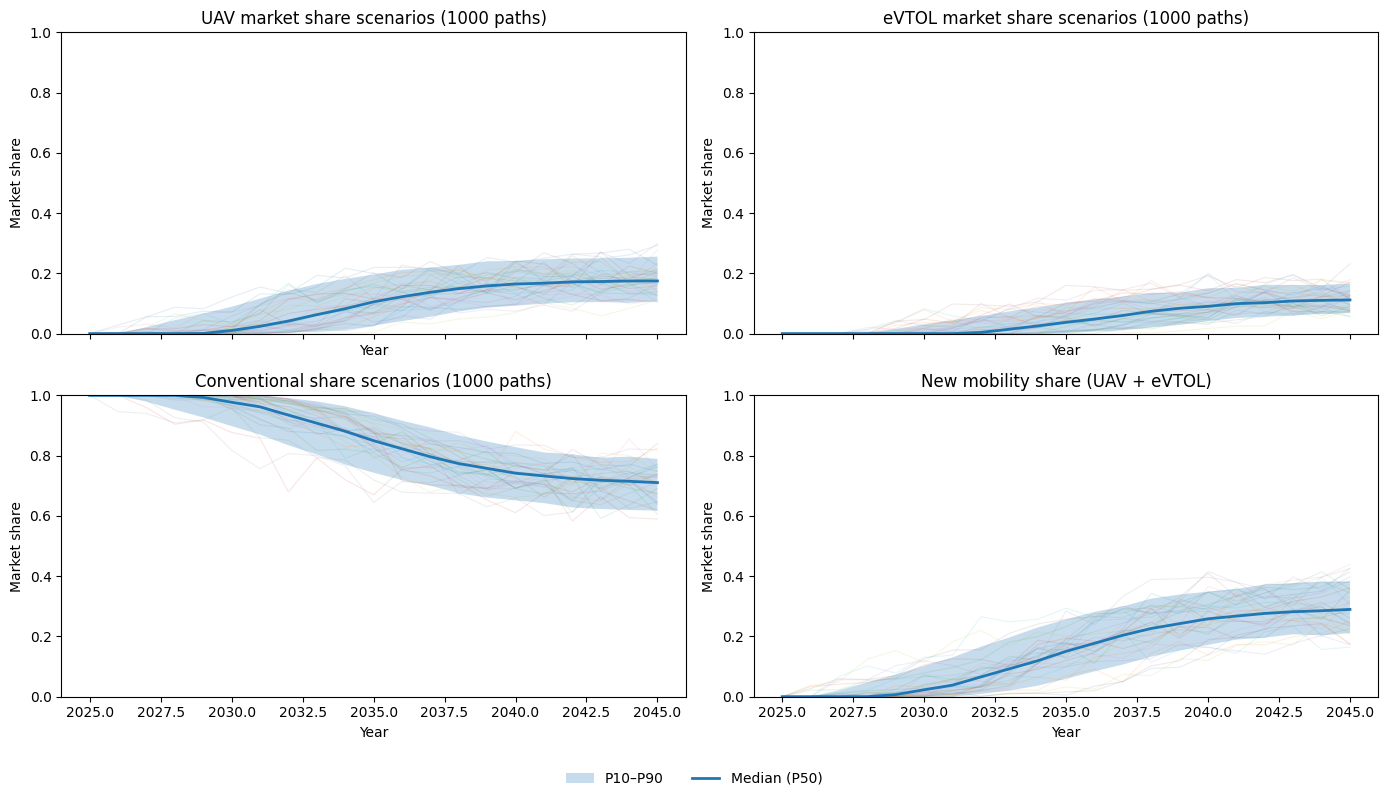

In [40]:
# ============================================================
# AEROVALE Market-Share Scenario Generator (1000+) + Plot
# - Realistic assumptions:
#   UAV entry:   2026–2032, K ~ 0.18 ± 0.05
#   eVTOL entry: 2028–2035, K ~ 0.12 ± 0.03
# - Adoption: logistic S-curve (diffusion)
# - Shares: always >=0 and sum to 1 (Dirichlet jitter around expected shares)
# ============================================================

def logistic(t, K, r, tau):
    return K / (1.0 + np.exp(-r * (t - tau)))

def truncnorm_sample(rng, mean, std, low, high):
    # simple rejection sampler (fast enough for scalar draws)
    while True:
        x = rng.normal(mean, std)
        if low <= x <= high:
            return float(x)

def fan_stats(x):  # x: (n_scen, T)
    q10 = np.quantile(x, 0.10, axis=0)
    q50 = np.quantile(x, 0.50, axis=0)
    q90 = np.quantile(x, 0.90, axis=0)
    return q10, q50, q90

def plot_share_fan(ax, years, share_paths, title, n_example=30, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    q10, q50, q90 = fan_stats(share_paths)

    # example paths
    n_scen = share_paths.shape[0]
    idx = rng.choice(n_scen, size=min(n_example, n_scen), replace=False)
    ax.plot(years, share_paths[idx].T, linewidth=0.8, alpha=0.12)

    # fan + median
    ax.fill_between(years, q10, q90, alpha=0.25, label="P10–P90")
    ax.plot(years, q50, linewidth=2.0, label="Median (P50)")

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Market share")
    ax.set_ylim(0, 1)

def generate_market_share_scenarios_realistic(
    years,
    n_scen=1000,
    groups=("conv", "uav", "evtol"),
    # Entry windows (calendar years)
    entry_uav=(2026, 2032),
    entry_evtol=(2028, 2035),
    # Saturation K (mean/std) = your "realistic values"
    K_uav_mean=0.18, K_uav_std=0.05, K_uav_bounds=(0.0, 0.50),
    K_evt_mean=0.12, K_evt_std=0.03, K_evt_bounds=(0.0, 0.40),
    # Adoption speed r (positive). These are “reasonable defaults”; tune if you want faster/slower ramp-up.
    r_uav_logn=(np.log(0.60), 0.40),   # mean in log-space, sigma
    r_evt_logn=(np.log(0.50), 0.50),
    # Time from entry to "take-off" midpoint (years)
    takeoff_delay=(2, 8),
    # Dirichlet concentration: higher = smoother/less noisy around the S-curve mean
    kappa=200,
    # reproducibility
    seed=42,
):
    rng = np.random.default_rng(seed)

    T = len(years)
    G = len(groups)
    idx = {g: i for i, g in enumerate(groups)}
    t = np.arange(T)

    shares = np.zeros((n_scen, T, G), dtype=float)

    for s in range(n_scen):
        # --- entry years -> indices ---
        y0_uav = int(rng.integers(entry_uav[0], entry_uav[1] + 1))
        y0_evt = int(rng.integers(entry_evtol[0], entry_evtol[1] + 1))

        t0_uav = int(np.clip(y0_uav - years[0], 0, T - 1))
        t0_evt = int(np.clip(y0_evt - years[0], 0, T - 1))

        # --- saturation levels K (truncated normal around your mean/std) ---
        Ku = truncnorm_sample(rng, K_uav_mean, K_uav_std, K_uav_bounds[0], K_uav_bounds[1])
        Ke = truncnorm_sample(rng, K_evt_mean, K_evt_std, K_evt_bounds[0], K_evt_bounds[1])

        # --- growth steepness r (lognormal, positive) ---
        ru = float(rng.lognormal(mean=r_uav_logn[0], sigma=r_uav_logn[1]))
        re = float(rng.lognormal(mean=r_evt_logn[0], sigma=r_evt_logn[1]))

        # --- inflection (midpoint) tau = entry + delay ---
        du = int(rng.integers(takeoff_delay[0], takeoff_delay[1] + 1))
        de = int(rng.integers(takeoff_delay[0], takeoff_delay[1] + 1))
        tau_u = t0_uav + du
        tau_e = t0_evt + de

        # --- raw penetrations (expected shares before normalization/jitter) ---
        pu = logistic(t, Ku, ru, tau_u)
        pe = logistic(t, Ke, re, tau_e)
        pu[:t0_uav] = 0.0
        pe[:t0_evt] = 0.0

        # --- ensure feasibility: conv is the remainder; if pu+pe > 1, scale down ---
        new_sum = pu + pe
        scale = np.ones(T)
        mask = new_sum > 1.0
        scale[mask] = 1.0 / new_sum[mask]
        pu2 = pu * scale
        pe2 = pe * scale
        conv = 1.0 - (pu2 + pe2)

        # expected share vector per year
        m = np.vstack([conv, pu2, pe2]).T  # (T,3)

        # --- Dirichlet jitter to create realistic year-to-year variability while keeping sum=1 ---
        alpha = np.clip(kappa * m, 1e-9, None)
        w = np.array([rng.dirichlet(alpha[t_i]) for t_i in range(T)])  # (T,3)

        shares[s, :, idx["conv"]] = w[:, 0]
        shares[s, :, idx["uav"]]  = w[:, 1]
        shares[s, :, idx["evtol"]] = w[:, 2]

    return shares

# =========================
# RUN (edit these)
# =========================
start_year = 2025
horizon_years = 20  # same planning horizon as Task 2
years = np.arange(start_year, start_year + horizon_years + 1)  # inclusive horizon

n_scen = 1000
shares = generate_market_share_scenarios_realistic(years, n_scen=n_scen)

# =========================
# PLOT (subplots)
# =========================
groups = ("conv", "uav", "evtol")
idx = {g: i for i, g in enumerate(groups)}
rng_plot = np.random.default_rng(123)

uav  = shares[:, :, idx["uav"]]
evtl = shares[:, :, idx["evtol"]]
conv = shares[:, :, idx["conv"]]
new  = uav + evtl

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

plot_share_fan(axes[0, 0], years, uav,  "UAV market share scenarios (1000 paths)", n_example=30, rng=rng_plot)
plot_share_fan(axes[0, 1], years, evtl, "eVTOL market share scenarios (1000 paths)", n_example=30, rng=rng_plot)
plot_share_fan(axes[1, 0], years, conv, "Conventional share scenarios (1000 paths)", n_example=30, rng=rng_plot)
plot_share_fan(axes[1, 1], years, new,  "New mobility share (UAV + eVTOL)", n_example=30, rng=rng_plot)

# shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

# =========================
# (Optional) quick sanity checks
# =========================
# print("Min share:", shares.min(), "Max share:", shares.max())
# print("Sum close to 1 (max abs error):", np.max(np.abs(shares.sum(axis=2) - 1.0)))

## 4. Options in and on systems

#### 4.1 Options on Systems:
- Option to Defer (Vertiports): Postpone the construction of Vertiports for eVTOLS until demand is sufficient. Keeping open space to implement
- Option to Stage (UAV Cargo Ports): Starting with a small Cargo UAV Terminal for example within GA Section helps test out with the option to gradually grow

#### 4.2 Options in Systems:
- Rooftop Vertiports: When a new Parking lot or other Terminal or Landside buildings are created, build them with the option to include Vertiports on the rooftop in the future as they provide a valuable and space-saving option.
- Build for Electricity: When building Apron and other new ground infrastructure, already include empty conduits ("leerrohre") for future electrification and recharging options for electric Aircraft.

## 5. Candidate Flexibility

#### Start with eVTOL Vertipads

At the beginning stage, we only want to create 1 or 2 trial eVTOL Vertipads with a charging station at a place where we can efficiently leave the airport terminal airspace. But it will be installed at a location, where we are able to expand the number of Vertipads without touching already existing infrastructure (option on system). Further, we want to already build the charging infrastructure and cabling in a way that we can expand the number of charging stations later without the need to completely rebuild the electric supply.

# Exercise 2


Regarding the eVTOL Stands: Always to be increased by 2 stands and 1 high power charger (K)
#### CAPEX
- High Power supply: $300'000 cabling from Grid to stands
- Costs per Stand: 200'000 $ 
- Cost per Charger: $120'000 
- Total: 520'000 $ per step increase
- Option in System: $45,000 for extended Cables that are able to expand.

#### OPEX
- Maintenance per stand: $50,000 / year
- Usage: 250 $ / landing


## Cost and Revenue
#### Revenue
- revenue from charging an eVTOL
- revenue from parking / usage fee
- demand of flight movements
- market share of eVTOL in total flight movements
- number of vertiports (Stands) and Chargers K = 2 stands and 1 charger

#### cost functions
- capex plus opex


In [41]:
import numpy as np

# ============================================================
# CREATE INPUT ARRAYS for ENPV (from your already-run code)
# ============================================================
# expects you already have in memory:
#   - years_all_clean
#   - paths_p_clean   (shape: (T, n_paths))  # passengers
#   - (optional) paths_f_clean (shape: (T, n_paths)) # movements
#   - generate_market_share_scenarios_realistic() from your market-share code

# -----------------------
# 1) Demand arrays (shape: (S,T))
# -----------------------
years = years_all_clean                              # (T,)
pax_total = paths_p_clean.T                          # (S,T)  S=n_paths
# mov_total = paths_f_clean.T                        # (S,T)  optional

# If you want "hub pax" but don't have it yet: simplest placeholder = total pax
pax_hub = pax_total.copy()

# -----------------------
# 2) Market share arrays aligned to the SAME years (shape: (S,T))
# -----------------------
# IMPORTANT: re-generate shares on exactly the same year grid as demand:
S, T = pax_total.shape
shares = generate_market_share_scenarios_realistic(
    years=years,
    n_scen=S,
    seed=42,                 # keep reproducible
    # keep your realistic assumptions as defaults (uav/eVTOL entry windows, K means/std, etc.)
)

groups = ("conv", "uav", "evtol")
idx = {g: i for i, g in enumerate(groups)}
evtol_share = shares[:, :, idx["evtol"]]            # (S,T)

# -----------------------
# 3) (Optional) quick checks
# -----------------------
assert evtol_share.shape == pax_total.shape
assert len(years) == pax_total.shape[1]
# shares sum to 1 (numerical tolerance)
# print("max |sum-1|:", np.max(np.abs(shares.sum(axis=2) - 1.0)))

# Now you have the ENPV inputs:
# years, pax_total, pax_hub, evtol_share

In [43]:
import numpy as np

# ============================================================
# 0) ASSUMPTIONS / INPUTS (you already have these from before)
# ============================================================
# years:      (T,) e.g. np.arange(2025, 2046)
# pax_total:  (S,T) demand scenarios (Task 2)
# evtol_share:(S,T) market share scenarios (Task 3)
# pax_hub:    (S,T) optional hub-passenger segment; if you don't have it, use pax_total

# If you don't have pax_hub, uncomment this:
# pax_hub = pax_total

# ============================================================
# 1) PARAMETERS (from your slide + 2 simple assumptions)
# ============================================================
r = 0.08  # discount rate

seats = 3.0
load_factor = 0.75

stands_per_step = 2
mu_landings_per_stand = 1500  # landings/year/stand (tune)

# revenue / cost per landing (simplified)
price_per_landing = 450.0      # $/landing (charging + usage fee revenue)
var_cost_per_landing = 250.0   # $/landing (usage cost)
maint_per_stand = 50_000.0     # $/year per stand

# CAPEX (per expansion step)
capex_per_step = 520_000.0
option_cost_flex = 45_000.0    # paid once at t=0 (flex only)

# ============================================================
# 2) DEMAND TRANSFORM: eVTOL passengers -> landings
# ============================================================
def evtol_landings(pax_hub, evtol_share):
    e_pax = pax_hub * evtol_share
    return e_pax / (seats * load_factor)  # landings/year

# ============================================================
# 3) COST + REVENUE FUNCTIONS (core of your report)
# ============================================================
def revenue(served_landings):
    return price_per_landing * served_landings

def opex(served_landings, K_steps):
    stands = stands_per_step * K_steps
    return maint_per_stand * stands + var_cost_per_landing * served_landings

def capex(deltaK_steps):
    return capex_per_step * deltaK_steps

def npv(cashflows):
    t = np.arange(cashflows.shape[-1])  # 0..T-1
    disc = 1 / (1 + r) ** t
    return np.sum(cashflows * disc, axis=-1)

# ============================================================
# 4) TWO STRATEGIES (minimal)
#    - Conventional: build K0 at t=0, never expand
#    - Flexible: start K_init, add 1 step when demand > capacity
# ============================================================
def simulate_conventional(ev_land, K0):
    # ev_land: (T,)
    T = ev_land.shape[0]
    K = np.full(T, K0, dtype=int)
    deltaK = np.zeros(T, dtype=int); deltaK[0] = K0

    cap = (stands_per_step * K) * mu_landings_per_stand
    served = np.minimum(ev_land, cap)

    CF = revenue(served) - opex(served, K) - capex(deltaK)
    return CF, K, served, cap

def simulate_flexible(ev_land, K_init):
    T = ev_land.shape[0]
    K = np.zeros(T, dtype=int)
    deltaK = np.zeros(T, dtype=int)

    K[0] = K_init
    deltaK[0] = K_init

    for t in range(T):
        if t > 0:
            K[t] = K[t-1]
        cap_t = (stands_per_step * K[t]) * mu_landings_per_stand
        if ev_land[t] > cap_t:          # simple trigger
            K[t] += 1
            deltaK[t] += 1

    cap = (stands_per_step * K) * mu_landings_per_stand
    served = np.minimum(ev_land, cap)

    CF = revenue(served) - opex(served, K) - capex(deltaK)
    CF[0] -= option_cost_flex
    return CF, K, served, cap

# ============================================================
# 5) ENPV for a given design choice (K0 or K_init)
# ============================================================
def enpv_conventional(pax_hub, evtol_share, K0):
    ev_land = evtol_landings(pax_hub, evtol_share)     # (S,T)
    npvs = []
    for s in range(ev_land.shape[0]):
        CF, *_ = simulate_conventional(ev_land[s], K0)
        npvs.append(npv(CF))
    npvs = np.array(npvs)
    return np.mean(npvs), npvs

def enpv_flexible(pax_hub, evtol_share, K_init):
    ev_land = evtol_landings(pax_hub, evtol_share)     # (S,T)
    npvs = []
    for s in range(ev_land.shape[0]):
        CF, *_ = simulate_flexible(ev_land[s], K_init)
        npvs.append(npv(CF))
    npvs = np.array(npvs)
    return np.mean(npvs), npvs

# ============================================================
# 6) "Optimization" (tiny grid search)
# ============================================================
def find_best_K(pax_hub, evtol_share, K_grid=range(0, 11)):
    best_c = (-np.inf, None)
    best_f = (-np.inf, None)

    for K in K_grid:
        enpv_c, _ = enpv_conventional(pax_hub, evtol_share, K0=K)
        if enpv_c > best_c[0]:
            best_c = (enpv_c, K)

        enpv_f, _ = enpv_flexible(pax_hub, evtol_share, K_init=K)
        if enpv_f > best_f[0]:
            best_f = (enpv_f, K)

    return {
        "best_conventional": {"ENPV": best_c[0], "K0_steps": best_c[1], "stands": 2*best_c[1], "chargers": best_c[1]},
        "best_flexible": {"ENPV": best_f[0], "K_init_steps": best_f[1], "stands_init": 2*best_f[1], "chargers_init": best_f[1]},
    }

# ============================================================
# USAGE (uncomment when you have arrays)
# ============================================================
results = find_best_K(pax_hub, evtol_share, K_grid=range(0, 11))
results

{'best_conventional': {'ENPV': np.float64(4875292.0199704785),
  'K0_steps': 9,
  'stands': 18,
  'chargers': 9},
 'best_flexible': {'ENPV': np.float64(11041170.42913099),
  'K_init_steps': 2,
  'stands_init': 4,
  'chargers_init': 2}}

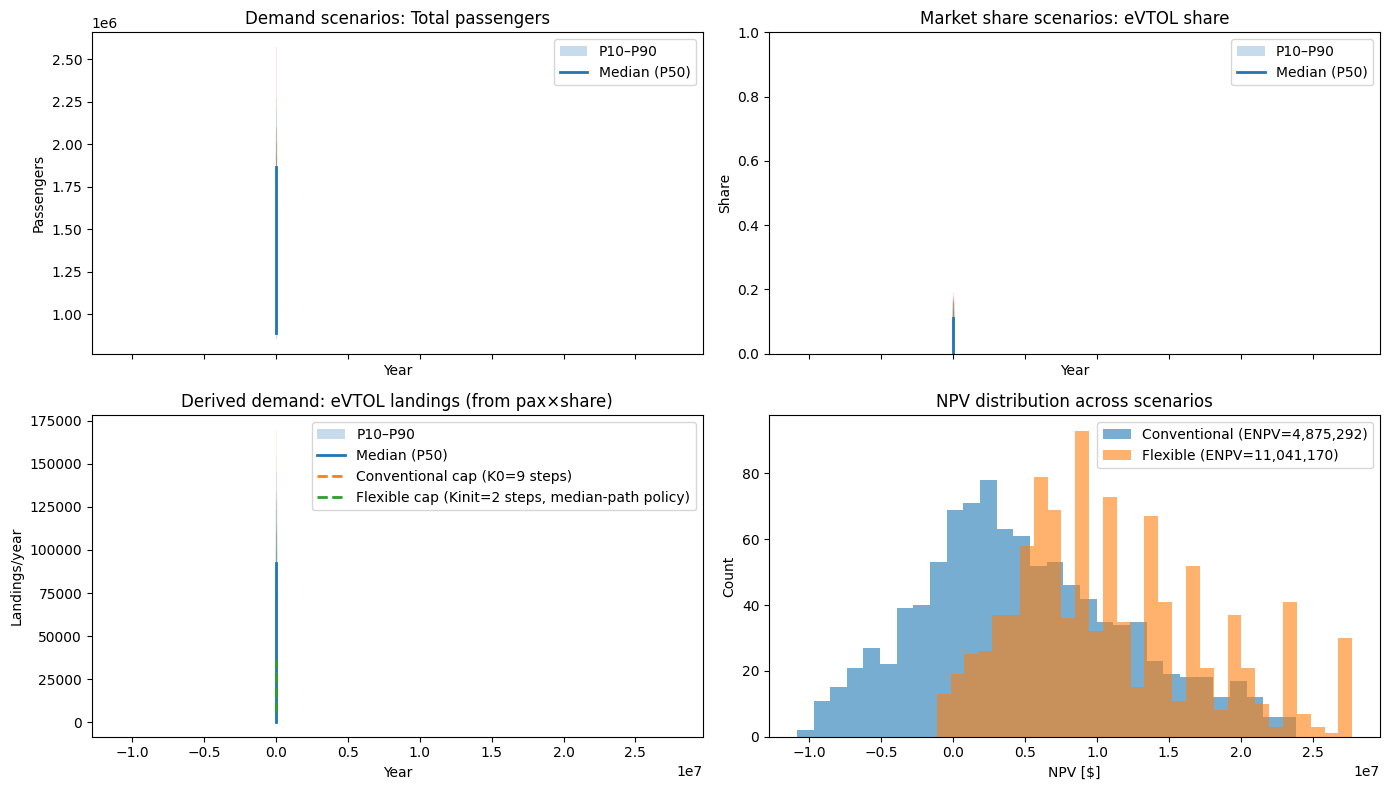

Best conventional: {'ENPV': np.float64(4875292.0199704785), 'K0_steps': 9, 'stands': 18, 'chargers': 9}
Best flexible: {'ENPV': np.float64(11041170.42913099), 'K_init_steps': 2, 'stands_init': 4, 'chargers_init': 2}
ENPV conventional: 4,875,292 $
ENPV flexible:     11,041,170 $


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PLOT EVERYTHING IMPORTANT (after you ran everything)
# expects in memory:
#   years              (T,)
#   pax_total          (S,T)
#   evtol_share        (S,T)
#
# optional (if you have them):
#   mov_total          (S,T)
#
# uses the same eVTOL conversion assumptions as ENPV model
# ============================================================

# --- assumptions (same as ENPV) ---
seats = 3.0
load_factor = 0.75

stands_per_step = 2
mu_landings_per_stand = 1500

def evtol_landings(pax_hub, evtol_share):
    return (pax_hub * evtol_share) / (seats * load_factor)

def fan(ax, x, paths, title, ylabel, n_example=30, seed=0):
    rng = np.random.default_rng(seed)
    q10 = np.quantile(paths, 0.10, axis=0)
    q50 = np.quantile(paths, 0.50, axis=0)
    q90 = np.quantile(paths, 0.90, axis=0)

    idx = rng.choice(paths.shape[0], size=min(n_example, paths.shape[0]), replace=False)
    ax.plot(x, paths[idx].T, linewidth=0.8, alpha=0.10)
    ax.fill_between(x, q10, q90, alpha=0.25, label="P10–P90")
    ax.plot(x, q50, linewidth=2.0, label="Median (P50)")

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)

def plot_capacity_lines(ax, years, K_steps, label_prefix=""):
    cap = (stands_per_step * K_steps) * mu_landings_per_stand
    ax.plot(years, cap, linewidth=2.0, linestyle="--", label=f"{label_prefix}capacity")

# -------------------------------
# 1) Derived arrays
# -------------------------------
pax_hub = pax_total  # if you created a separate pax_hub, replace here
e_land = evtol_landings(pax_hub, evtol_share)  # (S,T)

# -------------------------------
# 2) Quick "best K" (tiny grid) to overlay capacity
#    (requires your earlier minimal functions exist)
# -------------------------------
best = find_best_K(pax_hub, evtol_share, K_grid=range(0, 11))
K0_best = best["best_conventional"]["K0_steps"]
Kinit_best = best["best_flexible"]["K_init_steps"]

# Build one representative capacity path for flexible:
# We’ll simulate K(t) for the MEDIAN scenario (by median landings).
s_med = np.argsort(np.sum(e_land, axis=1))[len(e_land)//2]
CF_f, K_path_f, served_f, cap_f = simulate_flexible(e_land[s_med], Kinit_best)

# For conventional: constant K0
K_path_c = np.full_like(K_path_f, K0_best)
cap_c = (stands_per_step * K_path_c) * mu_landings_per_stand

# -------------------------------
# 3) Plots (2x2)
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# (A) Total passengers scenarios
fan(axes[0, 0], years, pax_total, "Demand scenarios: Total passengers", "Passengers", seed=1)
axes[0, 0].legend()

# (B) eVTOL market share scenarios
fan(axes[0, 1], years, evtol_share, "Market share scenarios: eVTOL share", "Share", seed=2)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()

# (C) eVTOL landings scenarios (+ capacity overlays for best designs)
fan(axes[1, 0], years, e_land, "Derived demand: eVTOL landings (from pax×share)", "Landings/year", seed=3)
axes[1, 0].plot(years, cap_c, linestyle="--", linewidth=2.0, label=f"Conventional cap (K0={K0_best} steps)")
axes[1, 0].plot(years, cap_f, linestyle="--", linewidth=2.0, label=f"Flexible cap (Kinit={Kinit_best} steps, median-path policy)")
axes[1, 0].legend()

# (D) ENPV distributions for best designs
# recompute NPV distributions for the best K values
enpv_c, npvs_c = enpv_conventional(pax_hub, evtol_share, K0_best)
enpv_f, npvs_f = enpv_flexible(pax_hub, evtol_share, Kinit_best)

axes[1, 1].hist(npvs_c, bins=30, alpha=0.6, label=f"Conventional (ENPV={enpv_c:,.0f})")
axes[1, 1].hist(npvs_f, bins=30, alpha=0.6, label=f"Flexible (ENPV={enpv_f:,.0f})")
axes[1, 1].set_title("NPV distribution across scenarios")
axes[1, 1].set_xlabel("NPV [$]")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# -------------------------------
# 4) Print quick summary
# -------------------------------
print("Best conventional:", best["best_conventional"])
print("Best flexible:", best["best_flexible"])
print(f"ENPV conventional: {enpv_c:,.0f} $")
print(f"ENPV flexible:     {enpv_f:,.0f} $")